### 라이브러리 import

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.max_columns',None)
import numpy as np
import random
import matplotlib.pyplot as plt

---

### 데이터 확인 및 전체 데이터 프레임 생성

In [2]:
# 데이터 불러오기 > 데이터 프레임 생성
df = pd.read_csv('./refine_input_ANM_data_231115.csv')

In [3]:
df.loc[df[df['평균초과속도'] < 0].index,'평균초과속도'] = 0

In [4]:
# 데이터 프레임 살펴보기
df.head(1)

,기준일자,장비고유구분,단속형태,설치지역,기상관측지역,기준연월,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,평균발생시각,단속건수,제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수,장비설치일자,설치경과일수,도로종류,구간유형,도로유형,도로선형
0,2020-02-01,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.4,-4.2,7.1,0.0,6.1,1.0,83.4,5.6,111008,68784,2021-01-31,-365,시도,일반구역,단일로,직선평지


In [5]:
# 컬럼 확인
df.columns

Index(['기준일자', '장비고유구분', '단속형태', '설치지역', '기상관측지역', '기준연월', '사고건수', '사망자수',
       '중상자수', '경상자수', '부상신고자수', '관련차량대수', '평균발생시각', '단속건수', '제한속도', '평균과속속도',
       '평균초과속도', '일평균기온', '일최저기온', '일최고기온', '일강수량', '일최대순간풍속', '일평균풍속',
       '일평균상대습도', '일평균중기압', '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수', '장비설치일자',
       '설치경과일수', '도로종류', '구간유형', '도로유형', '도로선형'],
      dtype='object')

In [6]:
# 컬럼별 값 확인
print(df.단속형태.value_counts())  # 신호위반, 속도위반, 구간과속
print(df.설치지역.value_counts())  # 경기도 시
print(df.기상관측지역.value_counts())  # 수원, 이천, 양평 -> 구분값 의미 크게 없음.
print(df.도로종류.value_counts())  # 시도, 지방도, 국도, 고속도로
print(df.구간유형.value_counts())  # 스쿨존, 일반구역, 실버존
print(df.도로유형.value_counts())  # 교차로, 단일로
print(df.도로선형.value_counts())

단속형태
신호위반    243090
속도위반     64970
구간과속      2920
Name: count, dtype: int64
설치지역
화성시    45990
안산시    44530
용인시    41610
평택시    25550
안성시    21900
부천시    21170
김포시    18250
성남시    13870
수원시    13870
광주시    12410
하남시     9490
여주시     8760
안양시     8030
오산시     5110
군포시     5110
시흥시     4380
양평군     3650
이천시     2920
과천시     2190
광명시     1460
의왕시      730
Name: count, dtype: int64
기상관측지역
수원    273750
이천     24090
양평     13140
Name: count, dtype: int64
도로종류
시도      224840
지방도      52560
국도       29200
고속도로      4380
Name: count, dtype: int64
구간유형
스쿨존     183230
일반구역    124830
실버존       2920
Name: count, dtype: int64
도로유형
교차로    224110
단일로     86870
Name: count, dtype: int64
도로선형
직선평지     256960
직선내리막     24090
좌내리막       9490
좌평지        5840
우평지        5840
직선오르막      5110
우내리막       2190
우오르막        730
좌오르막        730
Name: count, dtype: int64


In [7]:
# 인덱스 설정
df = df.set_index('기준일자')

In [8]:
# df 복제 후, 불필요 컬럼 제거
df_all = df.copy()
df_all = df_all.drop(columns = ['장비고유구분', '기준연월', '장비설치일자', '기상관측지역'])

In [9]:
# 컬럼 확인
df_all.columns

Index(['단속형태', '설치지역', '사고건수', '사망자수', '중상자수', '경상자수', '부상신고자수', '관련차량대수',
       '평균발생시각', '단속건수', '제한속도', '평균과속속도', '평균초과속도', '일평균기온', '일최저기온', '일최고기온',
       '일강수량', '일최대순간풍속', '일평균풍속', '일평균상대습도', '일평균중기압', '장비설치지역_주민등록인구수',
       '장비설치지역_차량등록대수', '설치경과일수', '도로종류', '구간유형', '도로유형', '도로선형'],
      dtype='object')

---

### 데이터 전처리

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

In [11]:
# 사고/단속 데이터 프레임 생성
df_acc = df_all[[
    # 단속 관련
    '단속형태', '설치지역', '설치경과일수',
    # 도로 관련
    '도로종류', '구간유형', '도로유형', '도로선형',
    # 날씨 관련
    '일평균기온', '일최저기온', '일최고기온', '일강수량', '일최대순간풍속', '일평균풍속', '일평균상대습도', '일평균중기압',
    # 인구 및 차량 관련
    '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수', 
    # 사고 관련
    '사고건수', '사망자수', '중상자수', '경상자수', '부상신고자수', '평균발생시각'
]]

df_vio = df_all[[
    # 단속 관련
    '단속형태', '설치지역', '설치경과일수',
    # 도로 관련
    '도로종류', '구간유형', '도로유형', '도로선형',
    # 날씨 관련
    '일평균기온', '일최저기온', '일최고기온', '일강수량', '일최대순간풍속', '일평균풍속', '일평균상대습도', '일평균중기압',
    # 인구 및 차량 관련
    '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수', 
    # 단속 수치 관련
    '단속건수', '제한속도', '평균과속속도', '평균초과속도'
]]

In [12]:
# 전처리용 df 복제
df_acc_pre = df_acc.copy()
df_vio_pre = df_vio.copy()

In [13]:
# 데이터 타입 확인
df_acc_pre.dtypes

단속형태               object
설치지역               object
설치경과일수              int64
도로종류               object
구간유형               object
도로유형               object
도로선형               object
일평균기온             float64
일최저기온             float64
일최고기온             float64
일강수량              float64
일최대순간풍속           float64
일평균풍속             float64
일평균상대습도           float64
일평균중기압            float64
장비설치지역_주민등록인구수      int64
장비설치지역_차량등록대수       int64
사고건수              float64
사망자수              float64
중상자수              float64
경상자수              float64
부상신고자수            float64
평균발생시각            float64
dtype: object

In [14]:
# train-test 나누기
df_acc_pre_train = df_acc_pre[df_acc_pre.설치경과일수 < 0]
df_acc_pre_test = df_acc_pre[df_acc_pre.설치경과일수 >= 0]

df_vio_pre_train = df_vio_pre[df_vio_pre.설치경과일수 < 183]  # 일자 맞는지 확인해주세요.
df_vio_pre_test = df_vio_pre[df_vio_pre.설치경과일수 >= 183]

In [15]:
# 수치형 데이터 추출
df_acc_pre_train_num = df_acc_pre_train.select_dtypes(["number"])
df_acc_pre_test_num = df_acc_pre_test.select_dtypes(["number"])

df_vio_pre_train_num = df_vio_pre_train.select_dtypes(["number"])
df_vio_pre_test_num = df_vio_pre_test.select_dtypes(["number"])

In [16]:
# 수치형 데이터 표준화 및 정규화(min-max): 종속변수 제외(사고건수, 평균초과속도)
con = (df_acc_pre_train_num.columns != '사고건수') & (df_acc_pre_train_num.columns != '평균초과속도')
df_acc_pre_train_num.loc[:, con] = StandardScaler().fit_transform(df_acc_pre_train_num.loc[:, con])
df_acc_pre_train_num.loc[:, con] = MinMaxScaler().fit_transform(df_acc_pre_train_num.loc[:, con])

con = (df_acc_pre_test_num.columns != '사고건수') & (df_acc_pre_test_num.columns != '평균초과속도')
df_acc_pre_test_num.loc[:, con] = StandardScaler().fit_transform(df_acc_pre_test_num.loc[:, con])
df_acc_pre_test_num.loc[:, con] = MinMaxScaler().fit_transform(df_acc_pre_test_num.loc[:, con])

con = (df_vio_pre_train_num.columns != '사고건수') & (df_vio_pre_train_num.columns != '평균초과속도')
df_vio_pre_train_num.loc[:, con] = StandardScaler().fit_transform(df_vio_pre_train_num.loc[:, con])
df_vio_pre_train_num.loc[:, con] = MinMaxScaler().fit_transform(df_vio_pre_train_num.loc[:, con])

con = (df_vio_pre_test_num.columns != '사고건수') & (df_vio_pre_test_num.columns != '평균초과속도')
df_vio_pre_test_num.loc[:, con] = StandardScaler().fit_transform(df_vio_pre_test_num.loc[:, con])
df_vio_pre_test_num.loc[:, con] = MinMaxScaler().fit_transform(df_vio_pre_test_num.loc[:, con])

In [17]:
# 범주형 데이터 추출
df_acc_pre_train_cat = df_acc_pre_train.select_dtypes(["object"])
df_acc_pre_test_cat = df_acc_pre_test.select_dtypes(["object"])

df_vio_pre_train_cat = df_vio_pre_train.select_dtypes(["object"])
df_vio_pre_test_cat = df_vio_pre_test.select_dtypes(["object"])

In [18]:
# 더미변수 생성
df_acc_pre_train_cat = pd.get_dummies(df_acc_pre_train_cat).astype(int)
df_acc_pre_test_cat = pd.get_dummies(df_acc_pre_test_cat).astype(int)
df_vio_pre_train_cat = pd.get_dummies(df_vio_pre_train_cat).astype(int)
df_vio_pre_test_cat = pd.get_dummies(df_vio_pre_test_cat).astype(int)

In [19]:
# 전처리 데이터 프레임 결합
df_acc_train = pd.concat([df_acc_pre_train_num, df_acc_pre_train_cat], axis=1)
df_acc_test = pd.concat([df_acc_pre_test_num, df_acc_pre_test_cat], axis=1)

df_vio_train = pd.concat([df_vio_pre_train_num, df_vio_pre_train_cat], axis=1)
df_vio_test = pd.concat([df_vio_pre_test_num, df_vio_pre_test_cat], axis=1)

***

### 예측 분석 수행

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score

In [21]:
# 독립/종속 변수 분리
acc_train_X = df_acc_train.iloc[:, df_acc_train.columns != '사고건수']
acc_train_y = df_acc_train.iloc[:, df_acc_train.columns == '사고건수']
acc_test_X = df_acc_test.iloc[:, df_acc_test.columns != '사고건수']
acc_test_y = df_acc_test.iloc[:, df_acc_test.columns == '사고건수']

vio_train_X = df_vio_train.iloc[:, df_vio_train.columns != '평균초과속도']
vio_train_y = df_vio_train.iloc[:, df_vio_train.columns == '평균초과속도']
vio_test_X = df_vio_test.iloc[:, df_vio_test.columns != '평균초과속도']
vio_test_y = df_vio_test.iloc[:, df_vio_test.columns == '평균초과속도']

In [22]:
# 훈련, 테스트 데이터 분리 (8:2)
acc_X_train, acc_X_test, acc_y_train, acc_y_test = train_test_split(acc_train_X, acc_train_y, test_size=0.2, random_state = 42)
vio_X_train, vio_X_test, vio_y_train, vio_y_test = train_test_split(vio_train_X, vio_train_y, test_size=0.2, random_state = 42)

#### 1) 선형 회귀

In [23]:
from sklearn.linear_model import LinearRegression
acc_LR_model = LinearRegression()
vio_LR_model = LinearRegression()

In [24]:
# training
acc_LR_model.fit(acc_X_train, acc_y_train)
vio_LR_model.fit(vio_X_train, vio_y_train)

LinearRegression()

In [25]:
# test 
acc_LR_pred = acc_LR_model.predict(acc_X_test)
vio_LR_pred = vio_LR_model.predict(vio_X_test)

In [26]:
# 평가
print(round(acc_LR_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_LR_pred), 2))
print(round(vio_LR_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_LR_pred), 2))

0.88 0.0
0.78 5.39


> 평균초과속도 값이 음수가 있음.. 확인 필요합니다.

In [27]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_LR_result = acc_test_y
acc_LR_result.사고건수 = list(np.clip(acc_LR_model.predict(acc_test_X), 0, None).flatten())

vio_LR_result = vio_test_y
vio_LR_result.평균초과속도 = list(np.clip(vio_LR_model.predict(vio_test_X), 0, None).flatten())

#### 2) 라쏘 회귀

In [28]:
from sklearn.linear_model import Lasso
alpha = 0.1  # 규제 강도 조절 매개변수
acc_lasso_model = Lasso(alpha=alpha)
vio_lasso_model = Lasso(alpha=alpha)

In [29]:
# training
acc_lasso_model.fit(acc_X_train, acc_y_train)
vio_lasso_model.fit(vio_X_train, vio_y_train)
# test
acc_lasso_pred = acc_lasso_model.predict(acc_X_test)
vio_lasso_pred = vio_lasso_model.predict(vio_X_test)

In [30]:
# 평가
print(round(acc_lasso_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_lasso_pred), 2))
print(round(vio_lasso_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_lasso_pred), 2))

-0.0 0.02
0.73 6.66


In [31]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_lasso_result = acc_test_y
acc_lasso_result.사고건수 = list(np.clip(acc_lasso_model.predict(acc_test_X), 0, None).flatten())

vio_lasso_result = vio_test_y
vio_lasso_result.평균초과속도 = list(np.clip(vio_lasso_model.predict(vio_test_X), 0, None).flatten())

#### 3) 릿지 회귀

In [32]:
from sklearn.linear_model import Ridge
alpha = 0.1
acc_ridge_model = Ridge(alpha=alpha)
vio_ridge_model = Ridge(alpha=alpha)

In [33]:
# training
acc_ridge_model.fit(acc_X_train, acc_y_train)
vio_ridge_model.fit(vio_X_train, vio_y_train)
# test
acc_ridge_pred = acc_ridge_model.predict(acc_X_test)
vio_ridge_pred = vio_ridge_model.predict(vio_X_test)

In [34]:
# 평가
print(round(acc_ridge_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_ridge_pred), 2))
print(round(vio_ridge_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_ridge_pred), 2))

0.88 0.0
0.78 5.39


In [35]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_ridge_result = acc_test_y
acc_ridge_result.사고건수 = list(np.clip(acc_ridge_model.predict(acc_test_X), 0, None).flatten())

vio_ridge_result = vio_test_y
vio_ridge_result.평균초과속도 = list(np.clip(vio_ridge_model.predict(vio_test_X), 0, None).flatten())

#### 4) 결정 트리

In [36]:
from sklearn.tree import DecisionTreeRegressor
acc_DT_model = DecisionTreeRegressor(random_state=42)
vio_DT_model = DecisionTreeRegressor(random_state=42)

In [37]:
# training
acc_DT_model.fit(acc_X_train, acc_y_train)
vio_DT_model.fit(vio_X_train, vio_y_train)
# test
acc_DT_pred = acc_DT_model.predict(acc_X_test)
vio_DT_pred = vio_DT_model.predict(vio_X_test)

In [38]:
# 평가
print(round(acc_DT_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_DT_pred), 2))
print(round(vio_DT_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_DT_pred), 2))

0.92 0.0
1.0 0.07


In [39]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_DT_result = acc_test_y
acc_DT_result.사고건수 = list(np.clip(acc_DT_model.predict(acc_test_X), 0, None).flatten())

vio_DT_result = vio_test_y
vio_DT_result.평균초과속도 = list(np.clip(vio_DT_model.predict(vio_test_X), 0, None).flatten())

#### 5) SVM

In [40]:
from sklearn.svm import SVR
acc_svm_model = SVR(kernel='linear')
vio_svm_model = SVR(kernel='linear')

In [41]:
# training
acc_svm_model.fit(acc_X_train, acc_y_train)
vio_svm_model.fit(vio_X_train, vio_y_train)
# test
acc_svm_pred = acc_svm_model.predict(acc_X_test)
vio_svm_pred = vio_svm_model.predict(vio_X_test)

In [42]:
# 평가
print(round(acc_svm_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_svm_pred), 2))
print(round(vio_svm_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_svm_pred), 2))

0.46 0.01
0.75 6.3


In [43]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_svm_result = acc_test_y
acc_svm_result.사고건수 = list(np.clip(acc_svm_model.predict(acc_test_X), 0, None).flatten())

vio_svm_result = vio_test_y
vio_svm_result.평균초과속도 = list(np.clip(vio_svm_model.predict(vio_test_X), 0, None).flatten())

#### 6) XGBoost

In [44]:
from xgboost import XGBRegressor
acc_xgboost_model = XGBRegressor()
vio_xgboost_model = XGBRegressor()

In [45]:
# training
acc_xgboost_model.fit(acc_X_train, acc_y_train)
vio_xgboost_model.fit(vio_X_train, vio_y_train)
# test
acc_xgboost_pred = acc_xgboost_model.predict(acc_X_test)
vio_xgboost_pred = vio_xgboost_model.predict(vio_X_test)

In [46]:
# 평가
print(round(acc_xgboost_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_xgboost_pred), 2))
print(round(vio_xgboost_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_xgboost_pred), 2))

0.97 0.0
1.0 0.06


In [47]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_xgboost_result = acc_test_y
acc_xgboost_result.사고건수 = list(np.clip(acc_xgboost_model.predict(acc_test_X), 0, None).flatten())

vio_xgboost_result = vio_test_y
vio_xgboost_result.평균초과속도 = list(np.clip(vio_xgboost_model.predict(vio_test_X), 0, None).flatten())

#### 7) 랜덤포레스트

In [48]:
from sklearn.ensemble import RandomForestRegressor
acc_rf_model = RandomForestRegressor()
vio_rf_model = RandomForestRegressor()

In [49]:
# training
acc_rf_model.fit(acc_X_train, acc_y_train)
vio_rf_model.fit(vio_X_train, vio_y_train)
# test
acc_rf_pred = acc_rf_model.predict(acc_X_test)
vio_rf_pred = vio_rf_model.predict(vio_X_test)

In [50]:
# 평가
print(round(acc_rf_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_rf_pred), 2))
print(round(vio_rf_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_rf_pred), 2))

0.96 0.0
1.0 0.04


In [51]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_rf_result = acc_test_y
acc_rf_result.사고건수 = list(np.clip(acc_rf_model.predict(acc_test_X), 0, None).flatten())

vio_rf_result = vio_test_y
vio_rf_result.평균초과속도 = list(np.clip(vio_rf_model.predict(vio_test_X), 0, None).flatten())

#### 8) KNN

In [52]:
from sklearn.neighbors import KNeighborsRegressor
acc_knn_model = KNeighborsRegressor()
vio_knn_model = KNeighborsRegressor()

In [53]:
# training
acc_knn_model.fit(acc_X_train, acc_y_train)
vio_knn_model.fit(vio_X_train, vio_y_train)
# test
acc_knn_pred = acc_knn_model.predict(acc_X_test)
vio_knn_pred = vio_knn_model.predict(vio_X_test)

In [54]:
# 평가
print(round(acc_knn_model.score(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_knn_pred), 2))
print(round(vio_knn_model.score(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_knn_pred), 2))

0.75 0.01
0.9 2.58


In [55]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_knn_result = acc_test_y
acc_knn_result.사고건수 = list(np.clip(acc_knn_model.predict(acc_test_X), 0, None).flatten())

vio_knn_result = vio_test_y
vio_knn_result.평균초과속도 = list(np.clip(vio_knn_model.predict(vio_test_X), 0, None).flatten())

#### 9) 딥러닝, 다층 퍼셉트론(keras)

In [56]:
from keras.models import Sequential
from keras.layers import Dense
import tensorflow.compat.v1 as tf
from keras import backend as K
acc_deep_model = Sequential()
acc_deep_model.add(Dense(10, input_dim = acc_X_train.shape[1], activation = 'relu'))
acc_deep_model.add(Dense(1))
acc_deep_model.compile(optimizer=tf.compat.v1.train.AdamOptimizer(), loss='mean_squared_error')

vio_deep_model = Sequential()
vio_deep_model.add(Dense(10, input_dim = vio_X_train.shape[1], activation = 'relu'))
vio_deep_model.add(Dense(1))
vio_deep_model.compile(optimizer=tf.compat.v1.train.AdamOptimizer(), loss='mean_squared_error')

2023-12-05 05:45:37.240116: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-05 05:45:37.527901: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-05 05:45:37.529706: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-05 05:45:43.349018: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [57]:
# training
acc_deep_model.fit(acc_X_train, acc_y_train, epochs=100, batch_size=10, verbose=0)
vio_deep_model.fit(vio_X_train, vio_y_train, epochs=100, batch_size=10, verbose=0)
# test
acc_deep_pred = acc_deep_model.predict(acc_X_test)
vio_deep_pred = vio_deep_model.predict(vio_X_test)

1460/1460 [==============================] - 1s 428us/step


In [58]:
# 평가
print(round(acc_deep_model.evaluate(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_deep_pred), 2))
print(round(vio_deep_model.evaluate(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_deep_pred), 2))

972/972 [==============================] - 1s 467us/step - loss: 9.9489e-04
0.0 0.0
1460/1460 [==============================] - 1s 480us/step - loss: 0.0828
0.08 0.08


In [59]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_deep_result = acc_test_y
acc_deep_result.사고건수 = list(np.clip(acc_deep_model.predict(acc_test_X), 0, None).flatten())

vio_deep_result = vio_test_y
vio_deep_result.평균초과속도 = list(np.clip(vio_deep_model.predict(vio_test_X), 0, None).flatten())

2423/2423 [==============================] - 1s 439us/step


#### 10) GRU

In [60]:
from keras.layers import GRU
acc_gru_model = Sequential()
acc_gru_model.add(GRU(50, input_shape=(acc_X_train.shape[1], 1)))
acc_gru_model.add(Dense(1))
acc_gru_model.compile(optimizer='adam', loss='mean_squared_error')

vio_gru_model = Sequential()
vio_gru_model.add(GRU(50, input_shape=(vio_X_train.shape[1], 1)))
vio_gru_model.add(Dense(1))
vio_gru_model.compile(optimizer='adam', loss='mean_squared_error')

In [61]:
# training
acc_gru_model.fit(acc_X_train, acc_y_train, epochs=100, batch_size=10, verbose=0)
vio_gru_model.fit(vio_X_train, vio_y_train, epochs=100, batch_size=10, verbose=0)
# test
acc_gru_pred = acc_gru_model.predict(acc_X_test)
vio_gru_pred = vio_gru_model.predict(vio_X_test)

1460/1460 [==============================] - 4s 2ms/step


In [62]:
# 평가
print(round(acc_gru_model.evaluate(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_gru_pred), 2))
print(round(vio_gru_model.evaluate(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_gru_pred), 2))

972/972 [==============================] - 3s 3ms/step - loss: 0.0010
0.0 0.0
1460/1460 [==============================] - 4s 3ms/step - loss: 24.6371
24.64 24.64


In [63]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_gru_result = acc_test_y
acc_gru_result.사고건수 = list(np.clip(acc_gru_model.predict(acc_test_X), 0, None).flatten())

vio_gru_result = vio_test_y
vio_gru_result.평균초과속도 = list(np.clip(vio_gru_model.predict(vio_test_X), 0, None).flatten())

2423/2423 [==============================] - 6s 3ms/step


#### 11) 1D CNN

In [64]:
from keras.layers import Conv1D, Flatten
acc_cnn_model = Sequential()
acc_cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(acc_X_train.shape[1], 1)))
acc_cnn_model.add(Flatten())
acc_cnn_model.add(Dense(1))
acc_cnn_model.compile(optimizer='adam', loss='mean_squared_error')

vio_cnn_model = Sequential()
vio_cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(vio_X_train.shape[1], 1)))
vio_cnn_model.add(Flatten())
vio_cnn_model.add(Dense(1))
vio_cnn_model.compile(optimizer='adam', loss='mean_squared_error')

In [65]:
# training
acc_cnn_model.fit(acc_X_train, acc_y_train, epochs=100, batch_size=10, verbose=0)
vio_cnn_model.fit(vio_X_train, vio_y_train, epochs=100, batch_size=10, verbose=0)
# test
acc_cnn_pred = acc_cnn_model.predict(acc_X_test)
vio_cnn_pred = vio_cnn_model.predict(vio_X_test)

1460/1460 [==============================] - 1s 569us/step


In [66]:
# 평가
print(round(acc_cnn_model.evaluate(acc_X_test, acc_y_test),2),
      round(mean_squared_error(acc_y_test, acc_cnn_pred), 2))
print(round(vio_cnn_model.evaluate(vio_X_test, vio_y_test), 2),
      round(mean_squared_error(vio_y_test, vio_cnn_pred), 2))

972/972 [==============================] - 1s 631us/step - loss: 9.8967e-04
0.0 0.0
1460/1460 [==============================] - 1s 630us/step - loss: 0.2947
0.29 0.29


In [67]:
# 기존 test 데이터를 예측 결과로 대체
# 예측값을 0이상으로 클리핑
acc_cnn_result = acc_test_y
acc_cnn_result.사고건수 = list(np.clip(acc_cnn_model.predict(acc_test_X), 0, None).flatten())

vio_cnn_result = vio_test_y
vio_cnn_result.평균초과속도 = list(np.clip(vio_cnn_model.predict(vio_test_X), 0, None).flatten())

2423/2423 [==============================] - 1s 566us/step


### 예측 결과 합친 후 최종 데이터 프레임 생성

> 성능 한계로,, 결정 트리까지 돌린 결과만 먼저 최종 테이블 생성하는 과정 작성했습니다. 추가 수행 후 추가 code 작성하면 됩니다.

# 모델 저장

import joblib

joblib.dump(acc_LR_model,'./model_pk/acc_LR_second_model.pkl')
joblib.dump(vio_LR_model,'./model_pk/vio_LR_second_model.pkl')

joblib.dump(acc_lasso_model,'./model_pk/acc_lasso_second_model.pkl')
joblib.dump(vio_lasso_model,'./model_pk/vio_lasso_second_model.pkl')

joblib.dump(acc_ridge_model,'./model_pk/acc_ridge_second_model.pkl')
joblib.dump(vio_ridge_model,'./model_pk/vio_ridge_second_model.pkl')

joblib.dump(acc_DT_model,'./model_pk/acc_DT_second_model.pkl')
joblib.dump(vio_DT_model,'./model_pk/vio_DT_second_model.pkl')

joblib.dump(acc_svm_model,'./model_pk/acc_svm_second_model.pkl')
joblib.dump(vio_svm_model,'./model_pk/vio_svm_second_model.pkl')

joblib.dump(acc_xgboost_model,'./model_pk/acc_xgboost_second_model.pkl')
joblib.dump(vio_xgboost_model,'./model_pk/vio_xgboost_second_model.pkl')

joblib.dump(acc_rf_model,'./model_pk/acc_rf_second_model.pkl')
joblib.dump(vio_rf_model,'./model_pk/vio_rf_second_model.pkl')

joblib.dump(acc_knn_model,'./model_pk/acc_knn_second_model.pkl')
joblib.dump(vio_knn_model,'./model_pk/vio_knn_second_model.pkl')

from keras.models import model_from_json

acc_deep_model_json = acc_deep_model.to_json()
vio_deep_model_json = vio_deep_model.to_json()
acc_gru_model_json = acc_gru_model.to_json()
vio_gru_model_json = vio_gru_model.to_json()

with open("./model_pk/acc_deep_model_Arc_SND.json", "w") as json_file:
    json_file.write(acc_deep_model_json)
acc_deep_model.save_weights("acc_deep_model_weights.h5")

with open("./model_pk/vio_deep_model_Arc_SND.json", "w") as json_file:
    json_file.write(vio_deep_model_json)
vio_deep_model.save_weights("vio_deep_model_weights.h5")

with open("./model_pk/acc_gru_model_Arc_SND.json", "w") as json_file:
    json_file.write(acc_gru_model_json)
acc_gru_model.save_weights("acc_gru_model_weights.h5")

with open("./model_pk/vio_gru_model_Arc_SND.json", "w") as json_file:
    json_file.write(vio_gru_model_json)
vio_gru_model.save_weights("vio_gru_model_weights.h5")

# Load model architecture from JSON
with open("acc_model_architecture.json", "r") as json_file:
    loaded_acc_model_json = json_file.read()
loaded_acc_model = model_from_json(loaded_acc_model_json)

# Load model weights from HDF5
loaded_acc_model.load_weights("acc_model_weights.h5")

# Now you can save/load the model using joblib if necessary
joblib.dump(loaded_acc_model, './model_pk/acc_deep_model.pkl')

In [68]:
# 모델별 예측 결과 통합
acc_result =  pd.concat([acc_LR_result, acc_lasso_result, acc_ridge_result, acc_DT_result,
                        acc_svm_result, acc_xgboost_result,acc_rf_result,acc_knn_result,acc_deep_result,acc_gru_result], axis =1)
vio_result =  pd.concat([vio_LR_result, vio_lasso_result, vio_ridge_result, vio_DT_result,
                        vio_svm_result, vio_xgboost_result,vio_rf_result,vio_knn_result,vio_deep_result,vio_gru_result], axis =1)

In [69]:
# 컬럼명 변경
acc_result.columns = ['LR_사고건수', 'lasso_사고건수', 'ridge_사고건수', 'DT_사고건수','SVM_사고건수','XG_사고건수','RF_사고건수','KNN_사고건수','DL_사고건수','GRU_사고건수']
vio_result.columns = ['LR_초과속도', 'lasso_초과속도', 'ridge_초과속도', 'DT_초과속도','SVM_초과속도','XG_초과속도','RF_초과속도','KNN_초과속도','DL_초과속도','GRU_초과속도']

In [70]:
# 장비구분 추가
df_acc['장비고유구분'] = df.장비고유구분
df_vio['장비고유구분'] = df.장비고유구분

In [71]:
from tqdm import tqdm
start_num = 0
end_num = 365
acc_end_df = pd.DataFrame()
n = 0 
for idx in tqdm(df_acc['장비고유구분'].unique()):
    main = df_acc[df_acc['장비고유구분'] == idx]
    vs_df = acc_result.iloc[start_num:end_num,:]
    result_df = pd.merge(main,vs_df, left_index=True, right_index=True, how='left')
    acc_end_df = pd.concat([acc_end_df,result_df])
    start_num += 365
    end_num += 365

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 426/426 [00:09<00:00, 47.14it/s]


In [72]:
start_num = 0
end_num = 182
vio_end_df = pd.DataFrame()
n = 0 
for idx in tqdm(df_vio['장비고유구분'].unique()):
    main = df_vio[df_vio['장비고유구분'] == idx]
    vs_df = vio_result.iloc[start_num:end_num,:]
    result_df = pd.merge(main,vs_df, left_index=True, right_index=True, how='left')
    vio_end_df = pd.concat([vio_end_df,result_df])
    start_num += 182
    end_num += 182

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 426/426 [00:09<00:00, 46.54it/s]


In [73]:
acc_end_df.reset_index(inplace=True)
vio_end_df.reset_index(inplace=True)

acc_end_df.to_csv('./use_data/result/mart/TB_ACC_RST_TRD_TRY.csv',index=False)
vio_end_df.to_csv('./use_data/result/mart/TB_VIO_RST_TRD_TRY.csv',index=False)

In [74]:
from datetime import datetime
with open('detecting_process.txt','w+') as f:
    f.write(datetime.datetime.now())

TypeError: write() argument must be str, not datetime.datetime

In [77]:
datetime.now()

datetime.datetime(2023, 12, 5, 22, 34, 43, 753713)

# AFTER FIND

In [94]:
import seaborn as sns

<AxesSubplot:xlabel='설치경과일수'>

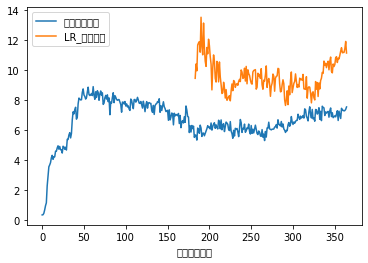

In [153]:
vio_end_df[vio_end_df['설치경과일수'] >=0].groupby(['설치경과일수']).agg({
    '평균초과속도': 'mean',
#    'LR_초과속도' : 'mean', 
#     'lasso_사고건수' : 'sum', 
#     'ridge_사고건수' : 'sum',
#     'DT_사고건수' : 'sum', 
#     'SVM_사고건수' : 'sum', 
#    'XG_초과속도' : 'mean', 
#     'RF_사고건수' : 'sum', 
#     'KNN_사고건수' : 'sum', 
#     'DL_사고건수' : 'sum',
#     'GRU_사고건수':'sum'
}).plot()

In [89]:
for idx in acc_end_df['장비고유구분'].unique():
    tmp = acc_end_df[acc_end_df['장비고유구분'] == idx]
    before = round(tmp[tmp['설치경과일수'].between(0,182)]['사고건수'].sum(),2)
    after = round(tmp[tmp['설치경과일수'].between(183,365)]['사고건수'].sum(),2)
    if before <after and before >= 5 and before > 0 and after > 0 : 
        print(f'{idx} : before : {before}, after : {after}')               

G6952 : before : 39.0, after : 40.0
G6953 : before : 10.0, after : 21.0
G6983 : before : 5.0, after : 7.0
G7608 : before : 8.0, after : 14.0
G7610 : before : 16.0, after : 21.0
G7612 : before : 9.0, after : 14.0
G7613 : before : 10.0, after : 15.0
G7644 : before : 6.0, after : 8.0
G8019 : before : 17.0, after : 20.0
G8566 : before : 20.0, after : 29.0
G8648 : before : 59.0, after : 63.0
G8649 : before : 19.0, after : 21.0
G8656 : before : 13.0, after : 17.0
G8672 : before : 6.0, after : 7.0
G9155 : before : 9.0, after : 15.0
G9581 : before : 17.0, after : 19.0
G9583 : before : 26.0, after : 55.0
H0637 : before : 34.0, after : 41.0
H0689 : before : 8.0, after : 15.0
H1375 : before : 48.0, after : 55.0
H1380 : before : 16.0, after : 27.0
H1381 : before : 19.0, after : 31.0
H1389 : before : 29.0, after : 36.0
H1390 : before : 34.0, after : 35.0
H1393 : before : 5.0, after : 7.0
경부고속도로390 : before : 29.0, after : 47.0


<AxesSubplot:xlabel='경과일수구간'>

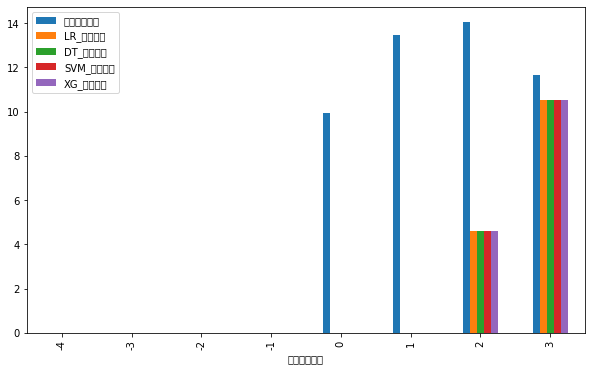

In [83]:
tmp = vio_end_df[vio_end_df['장비고유구분'] == 'G8022']

tmp['경과일수구간'] = tmp['설치경과일수'].apply(lambda x: x//100)

tmp.groupby(['경과일수구간']).agg({'평균초과속도':'mean',
                            'LR_초과속도':'mean',
                            'DT_초과속도':'mean',
                             'SVM_초과속도':'mean',
                             'XG_초과속도':'mean'
                            }).plot(kind='bar', figsize=(10, 6))

<AxesSubplot:xlabel='경과일수구간'>

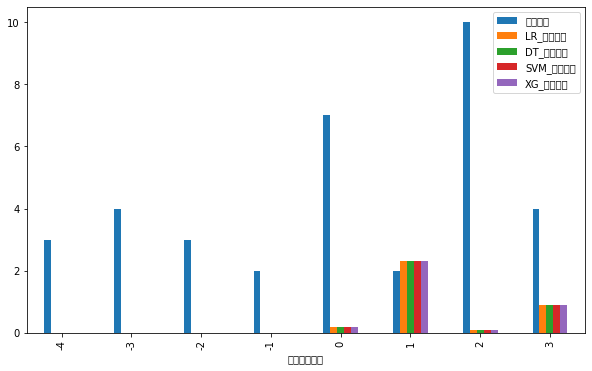

In [90]:
tmp = acc_end_df[acc_end_df['장비고유구분'] == 'G7612']

tmp['경과일수구간'] = tmp['설치경과일수'].apply(lambda x: x//100)

tmp.groupby(['경과일수구간']).agg({'사고건수':'sum',
                            'LR_사고건수':'sum',
                            'DT_사고건수':'sum',
                             'SVM_사고건수':'sum',
                             'XG_사고건수':'sum'
                            }).plot(kind='bar', figsize=(10, 6))